# Quantum Simulated Annealing with TLNAN
Sergio A. Ortega and Daniel K. Park

In this notebook we show the simulation of an algorithm for preparing the stationary distribution of a reversible Markov chain using Szegedy quantum walk and quantum phase estimation.

For reference, see section V. B. of our paper:

**[S. A. Ortega and M. A. Martin-Delgado. SQUWALS: A Szegedy QUantum WALks Simulator. Advanced Quantum Technologies, 7:2400022, 2024.](https://advanced.onlinelibrary.wiley.com/doi/full/10.1002/qute.202400022)**


First we import the libraries that we need, including our simulator library, and utils.

In [1]:
import sys
sys.path.insert(0, '../')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

import tlnan as tl

import utils

We want to obtain the stationary distribution for a reversible Markov chain which in this example comes from the Metropolis-Hasting algorithm applied to a 1D spin chain Ising model with $n=10$ qubits, with inverse temperature $\beta=1$.

We calculate the energy of the $N=2^n$ different states, and the transition probabilities between states, i.e., the weights of each edge. In this case, only transitions given by a single bit-flip are allowed.

In [3]:
n = 10

N = 2**n

beta = 1

energy = utils.calculate_energys(n)

edges_weight = utils.calculate_transition_list(energy,beta) # List with (from state, to state, probability).

In [4]:
# edges_weight

The associated graph is sparse, so that we use the sparse framework for simulating the walk. For that, we define the space data using the list of weights, which contains the edges of the graphs.

Note that since we are going to use the formulation with the update operator $V$, we need to add edges to node $0$.

In [5]:
sd = tl.SpaceData(edges_weight,add_zeroes=True)

We now use the space data with the weights list to obtain the sparse transition matrix.

In [6]:
transition_matrix = sd.obtain_transition_matrix(edges_weight)

Let us obtain the true Boltzmann distribution to check later.

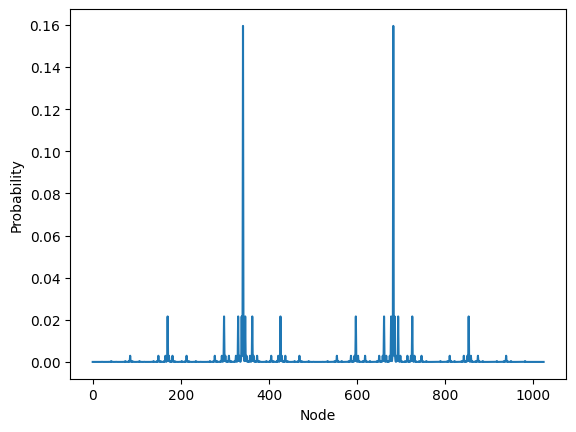

In [7]:
desired_boltzmann_distribution = utils.calculate_exact_distribution(energy, beta=1)

plt.plot(desired_boltzmann_distribution)
plt.xlabel('Node')
plt.ylabel('Probability')
plt.show()

Now, we want to obtain it using the QSA algorithm. We do it with $3$ qubits for the phase register, and 5 cooling steps from $\beta=0$ to $\beta=1$.

In [8]:
ph_qubits = 3

steps = 5

beta_list = np.linspace(0,1,steps+1)

We perform the QPE algorithm for each step, taking as initial state in the walk register the state that results of measuring $0$ in the phase register. For $\beta = 0$ we take the uniform distribution.

For each step, we save the probability of measuring phase $0$, as well as the joint probability of measuring $0$ at all the steps.

We also plot the distribution obtained by measuring the first register of the walk space, to compare it to the classical stationary distribution for each temperature.

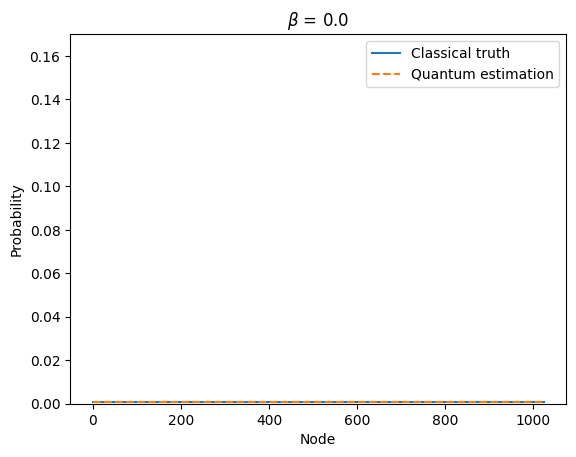

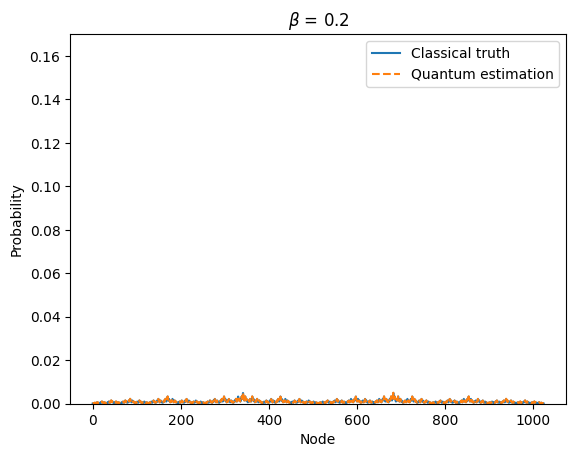

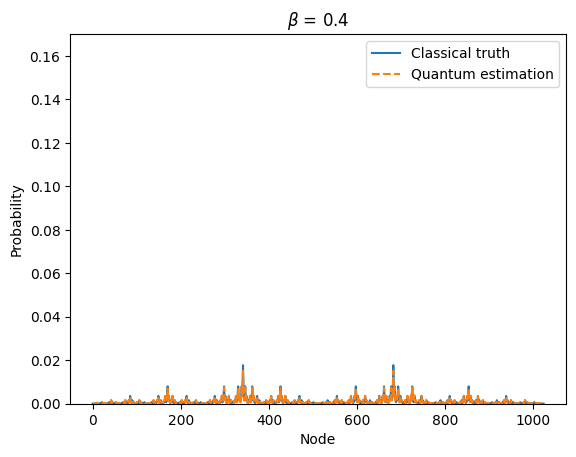

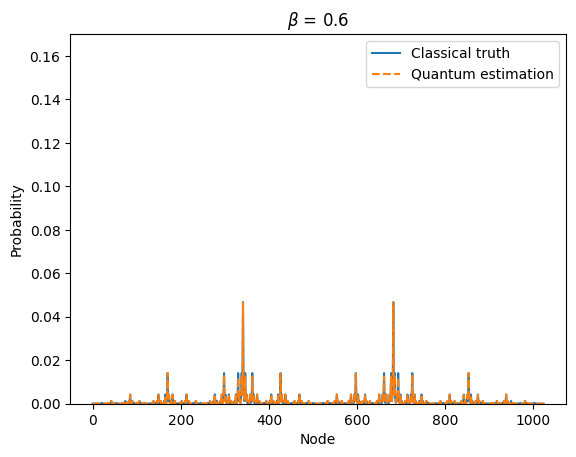

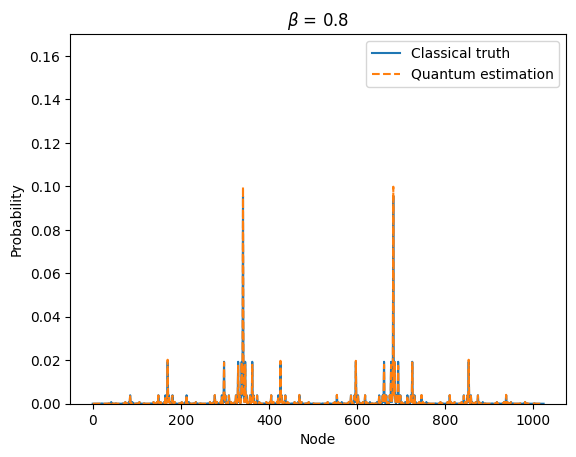

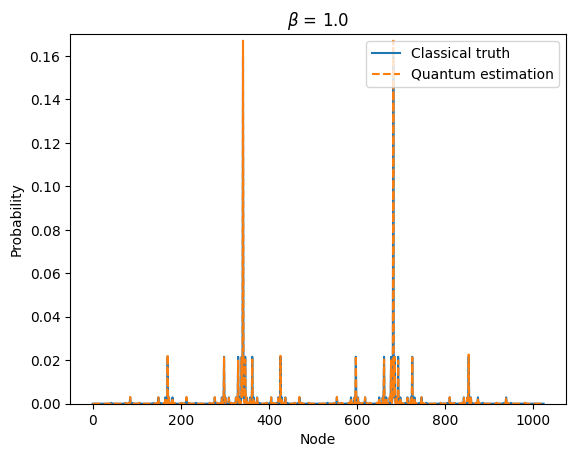

In [9]:
prob_0_step = []
joint_probability = []

sz_state = sd.create_no_coin_state(N) # Uniform distribution.

measurement = sd.Measurement(1) # Operator for measuring the first register of the walk.

measurement_phase = tl.qpe.PhaseMeasurement() # Operator for measuring the phase register.

for step in range(steps+1):
    
    # Obtain the transition matrix for the particular beta.
    
    beta = beta_list[step]
    edges_weight = utils.calculate_transition_list(energy,beta) # List with (from state, to state, probability).
    transition_matrix = sd.obtain_transition_matrix(edges_weight)
    
    # Obtain the exact Boltzmann distribution for comparing.
    
    boltzmann_distribution = utils.calculate_exact_distribution(energy, beta)
    plt.plot(boltzmann_distribution,label='Classical truth')
    
    # Walk oeprators.
    
    V = sd.Update(transition_matrix)
    Vd = V.inverse()
    R0 = sd.Reflection0()
    S = sd.Swap()
    W = Vd * S * V * R0
    W = Vd * S * V * R0 * Vd * S * V * R0
    
    # Perform the QPE algorithm.
    
    state_after_qpe = tl.qpe.direct_qpe(W,sz_state,ph_qubits)
    
    phase_probs = measurement_phase.operate(state_after_qpe)
    
    # Take the state for phase 0.
    
    sz_state = state_after_qpe[:,0]
    
    prob_0 = phase_probs[0]
    
    prob_0 = np.sum(abs(sz_state)**2)
    
    # Normalize the state.
    
    sz_state = sz_state / np.sqrt(sz_state@sz_state)
    
    # Measure the first register of the walk.
    
    quantum_distribution = measurement.operate(sz_state)
    
    plt.plot(quantum_distribution,'--',label='Quantum estimation')
    plt.xlabel('Node')
    plt.ylabel('Probability')
    plt.legend(loc=1)
    plt.ylim([0,0.17])
    plt.title(rf'$\beta$ = {beta:.1f}')
    plt.show()
    
    # Save the probabilities.
    
    prob_0_step.append(prob_0)
    joint_probability.append(np.prod(prob_0_step))

As we can see, for each temperature, the walk state reproduces the classical stationary distribution when the result of the phase register is $0$.

Let us now plot the probability of measuring $0$ in the phase register at each step, as well as the joint probability of all the steps so far resutling in phase $0$.

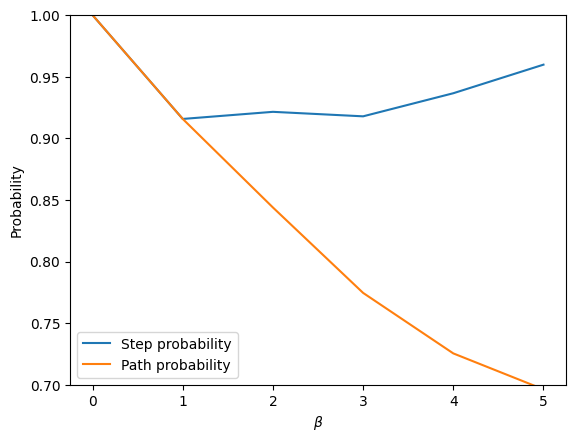

Probability of measuring phase 0 at all steps: 0.6962563195443151


In [10]:
plt.plot(prob_0_step)
plt.plot(joint_probability)


total_prob_0 = np.prod(prob_0_step)


plt.ylim([0.7,1])
plt.xlabel(r'$\beta$')
plt.ylabel('Probability')
plt.legend(['Step probability','Path probability'])
plt.show()

print(f'Probability of measuring phase 0 at all steps: {total_prob_0}')

The probability at each step is above $0.9$. However, the total probability of measuring $0$ for all the steps ends up decreasing to $0.7$. This is so because there are few cooling steps, so that it is not adiabatic enough.

We now simulate the QSA protocol for different number of cooling steps from $\beta = 0$ to $\beta = 1$, and save the joint probability of measuring phase $0$ at all the cooling steps.

In [11]:
final_probs = []

max_steps = 50

steps_range = np.arange(1,max_steps+1)

for steps in steps_range:
    
    beta_list = np.linspace(0,1,steps+1)
    
    sz_state = sd.create_no_coin_state(N) # Uniform distribution.
    
    measurement = sd.Measurement(1) # Operator for measuring the first register of the walk.

    measurement_phase = tl.qpe.PhaseMeasurement() # Operator for measuring the phase register.
    
    prob_0_step = []
    
    for step in range(steps+1):
        
        # Obtain the transition matrix for the particular beta.
        
        beta = beta_list[step]
        edges_weight = utils.calculate_transition_list(energy,beta) # List with (from state, to state, probability).
        transition_matrix = sd.obtain_transition_matrix(edges_weight)
        
        # Walk oeprators.
        
        V = sd.Update(transition_matrix)
        Vd = V.inverse()
        R0 = sd.Reflection0()
        S = sd.Swap()
        W = Vd * S * V * R0
        W = Vd * S * V * R0 * Vd * S * V * R0
        
        # Perform the QPE algorithm.
        
        state_after_qpe = tl.qpe.direct_qpe(W,sz_state,ph_qubits)
        
        phase_probs = measurement_phase.operate(state_after_qpe)
        
        # Take the state for phase 0.
        
        sz_state = state_after_qpe[:,0]
        
        prob_0 = phase_probs[0]
        
        # Normalize the state.
        
        sz_state = sz_state / np.sqrt(sz_state@sz_state)
        
        prob_0_step.append(prob_0)
    
    
    # Save the joint probability of measuring phase 0.
    
    total_prob_0 = np.prod(prob_0_step)
        
    final_probs.append(total_prob_0)
    
    print(f'Simulation for {steps} colling steps done.')

Simulation for 1 colling steps done.
Simulation for 2 colling steps done.
Simulation for 3 colling steps done.
Simulation for 4 colling steps done.
Simulation for 5 colling steps done.
Simulation for 6 colling steps done.
Simulation for 7 colling steps done.
Simulation for 8 colling steps done.
Simulation for 9 colling steps done.
Simulation for 10 colling steps done.
Simulation for 11 colling steps done.
Simulation for 12 colling steps done.
Simulation for 13 colling steps done.
Simulation for 14 colling steps done.
Simulation for 15 colling steps done.
Simulation for 16 colling steps done.
Simulation for 17 colling steps done.
Simulation for 18 colling steps done.
Simulation for 19 colling steps done.
Simulation for 20 colling steps done.
Simulation for 21 colling steps done.
Simulation for 22 colling steps done.
Simulation for 23 colling steps done.
Simulation for 24 colling steps done.
Simulation for 25 colling steps done.
Simulation for 26 colling steps done.
Simulation for 27 col

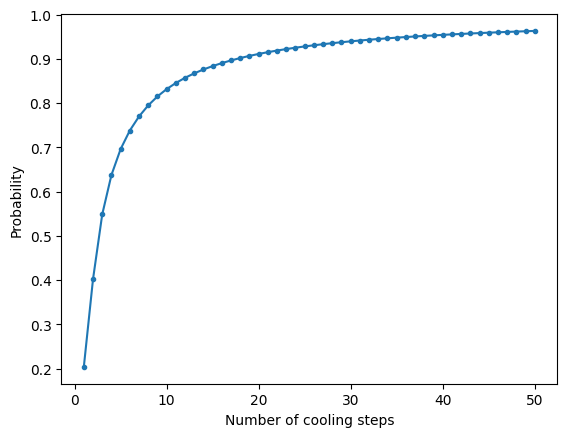

In [12]:
plt.plot(steps_range,final_probs,'.-')
plt.xlabel('Number of cooling steps')
plt.ylabel('Probability')
plt.show()

As expected, as the number of cooling steps increases, the probability of obtaining the desired result at the end of the QSA protocol increases near to $1$.

Finally, let us plot the distribution that is obtained by the QSA algorithm with $50$ cooling steps, when the phase register produces result $0$ in all the measurements.

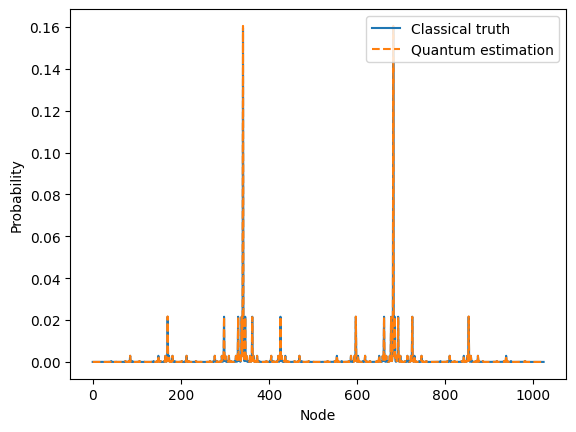

In [13]:
quantum_distribution = measurement.operate(sz_state)
    
plt.plot(desired_boltzmann_distribution,label='Classical truth')
plt.plot(quantum_distribution,'--',label='Quantum estimation')
plt.xlabel('Node')
plt.ylabel('Probability')
plt.legend(loc=1)
plt.show()

As expected, it matches the classical Boltzmann distriution we were interested in.